# Pregunta 4
## Las regiones con mayor desarrollo economico presentan un mejor desempeno educativo?

**Avance del proyecto 2026-1 hasta la semana 3**

Este notebook deja documentado el avance correspondiente a:

- Semana 1: inicio del proyecto.
- Semana 2: analisis exploratorio inicial.
- Semana 3: profundizacion del contexto.

**Advertencia metodologica.** Los archivos disponibles no contienen una medida academica directa como puntaje SIMCE o notas finales por region. Por eso, en este avance se usa el **IDPS 2022** (Indicadores de Desarrollo Personal y Social) como aproximacion al desempeno educativo. Ademas, el archivo de PIB regional disponible esta incompleto para este cruce porque no incluye Magallanes de forma usable, por lo que el analisis final se hace con **15 regiones comparables**. Como apoyo contextual, tambien se usa la base urbana del Censo 2024 de la pregunta 3.

### Ruta de trabajo usada en este avance

1. Limpiar y ordenar el archivo de PIB regional de la carpeta 4.
2. Agregar los puntajes IDPS 2022 por region usando los datos de la pregunta 2.
3. Construir indicadores regionales de ingreso y pobreza con CASEN 2022 para complementar la idea de desarrollo economico.
4. Incorporar la base urbana del Censo 2024 de la pregunta 3 como contexto regional adicional.
5. Comparar patrones iniciales entre actividad economica regional y desempeno educativo, dejando claras las limitaciones del cruce.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 110

BASE4 = Path.cwd()
BASE2 = BASE4.parent / 'pregunta 2'
BASE3 = BASE4.parent / 'pregunta 3'


In [2]:
pib_raw = pd.read_excel(BASE4 / 'CCNN2018_PIB_REGIONAL_T.xlsx', sheet_name='Cuadro', header=None)
pib_meta = pd.read_excel(BASE4 / 'CCNN2018_PIB_REGIONAL_T.xlsx', sheet_name='Metadatos')
idps_2m = pd.read_csv(BASE2 / 'idps2m2022_rbd_dim_final.csv', sep=';', encoding='latin1')
idps_4b = pd.read_csv(BASE2 / 'idps4b2022_rbd_dim_final.csv', sep=';', encoding='latin1')
casen = pd.read_excel(BASE2 / 'casen_reducido.xlsx')
censo_urbano = pd.read_csv(
    BASE3 / 'Base_urbanos_CPV24.csv',
    sep=';',
    decimal=',',
    usecols=['COD_REGION', 'REGION', 'n_per', 'prom_escolaridad18', 'n_asistencia_media', 'n_asistencia_superior', 'n_internet'],
    low_memory=False
)


## Semana 1. Inicio del proyecto

### Pregunta de trabajo

La pregunta del grupo es:

> **Las regiones con mayor desarrollo economico presentan un mejor desempeno educativo?**

### Justificacion inicial

La pregunta es relevante porque busca conectar dos dimensiones que suelen analizarse por separado:

- el desarrollo economico territorial,
- y los resultados educacionales que se observan en cada region.

### Decision metodologica inicial

Con los datos efectivamente disponibles, la unidad de analisis mas consistente es la **region**. En esta etapa se combinan cuatro fuentes:

- el archivo de **PIB regional** de la carpeta 4,
- los puntajes **IDPS 2022** por establecimiento de la carpeta 2,
- la base **CASEN 2022** para complementar el contexto socioeconomico regional,
- y la base **Base_urbanos_CPV24.csv** de la pregunta 3 para agregar contexto urbano sobre escolaridad, asistencia e internet.

Tambien se revisaron los archivos de la **pregunta 5**, pero no se incorporaron al analisis principal porque describen matricula y oferta universitaria por carrera o sede, no una medida directa de desempeno escolar regional ni la region de origen del estudiante.

### Hipotesis preliminar

Una hipotesis intuitiva seria esperar que las regiones con mayor actividad economica presenten tambien mejores resultados educativos. Sin embargo, esta relacion no tiene por que ser automatica. El tamano de la region, la desigualdad interna, la ruralidad y el tipo de establecimientos pueden modificar bastante el patron observado.

In [3]:
resumen_fuentes = pd.DataFrame([
    {
        'dataset': 'CCNN2018_PIB_REGIONAL_T.xlsx',
        'unidad_observacion': 'region x anio',
        'filas': pib_raw.shape[0],
        'columnas': pib_raw.shape[1],
        'aporte_al_analisis': 'Entrega una serie de PIB regional en volumen, util para aproximar actividad economica regional.'
    },
    {
        'dataset': 'idps2m2022_rbd_dim_final.csv',
        'unidad_observacion': 'establecimiento x dimension',
        'filas': len(idps_2m),
        'columnas': idps_2m.shape[1],
        'aporte_al_analisis': 'Permite construir el promedio regional de IDPS en II medio.'
    },
    {
        'dataset': 'idps4b2022_rbd_dim_final.csv',
        'unidad_observacion': 'establecimiento x dimension',
        'filas': len(idps_4b),
        'columnas': idps_4b.shape[1],
        'aporte_al_analisis': 'Permite construir el promedio regional de IDPS en 4to basico.'
    },
    {
        'dataset': 'casen_reducido.xlsx',
        'unidad_observacion': 'persona',
        'filas': len(casen),
        'columnas': casen.shape[1],
        'aporte_al_analisis': 'Aporta ingreso, pobreza y escolaridad para contextualizar el desarrollo regional en 2022.'
    },
    {
        'dataset': 'Base_urbanos_CPV24.csv',
        'unidad_observacion': 'entidad urbana/localidad',
        'filas': len(censo_urbano),
        'columnas': censo_urbano.shape[1],
        'aporte_al_analisis': 'Entrega contexto urbano regional sobre escolaridad, asistencia e internet desde el Censo 2024.'
    }
])

fuentes_evaluadas_no_usadas = pd.DataFrame([
    {
        'dataset': 'ArchivoMatr_Adm2022.csv y libro de codigos ADM 2022',
        'decision': 'No incorporado al analisis principal',
        'motivo': 'Permite estudiar oferta o matricula universitaria, pero no mide desempeno escolar regional ni identifica la region de origen del estudiante.'
    }
])

metadatos_pib_clave = pib_meta.iloc[:6, :2].copy()
metadatos_pib_clave.columns = ['campo', 'valor']

print('Resumen de fuentes utilizadas')
display(resumen_fuentes)
print()
print('Fuentes revisadas pero no usadas como variable principal')
display(fuentes_evaluadas_no_usadas)
print()
print('Metadatos clave del archivo de PIB regional')
display(metadatos_pib_clave)


Resumen de fuentes utilizadas


,dataset,unidad_observacion,filas,columnas,aporte_al_analisis
0,CCNN2018_PIB_REGIONAL_T.xlsx,region x anio,15,16,"Entrega una serie de PIB regional en volumen, ..."
1,idps2m2022_rbd_dim_final.csv,establecimiento x dimension,32736,19,Permite construir el promedio regional de IDPS...
2,idps4b2022_rbd_dim_final.csv,establecimiento x dimension,78815,19,Permite construir el promedio regional de IDPS...
3,casen_reducido.xlsx,persona,202231,15,"Aporta ingreso, pobreza y escolaridad para con..."
4,Base_urbanos_CPV24.csv,entidad urbana/localidad,848,7,Entrega contexto urbano regional sobre escolar...



Fuentes revisadas pero no usadas como variable principal


,dataset,decision,motivo
0,ArchivoMatr_Adm2022.csv y libro de codigos ADM...,No incorporado al analisis principal,Permite estudiar oferta o matricula universita...



Metadatos clave del archivo de PIB regional


,campo,valor
0,Unidad,Miles de millones de pesos
1,Frecuencia,TRIMESTRAL
2,Fuente,Banco Central de Chile
3,Última actualización,23-12-2025
4,Primera observación,01-01-1996
5,Última observación,01-07-2025


## Semana 2. Analisis exploratorio inicial

### Importacion y limpieza preliminar

La etapa exploratoria exige corregir primero el formato de las bases:

- el archivo de PIB viene con encabezados desplazados y requiere limpieza antes de usarlo,
- los puntajes educativos se encuentran a nivel de establecimiento y deben agregarse por region,
- CASEN debe resumirse por region para ofrecer una medida complementaria del contexto socioeconomico,
- y la base urbana del Censo 2024 debe agregarse por region para obtener indicadores contextuales comparables.

Ademas, el archivo de PIB disponible deja fuera a Magallanes en el cruce usable, por lo que se trabaja con **15 regiones comparables**.

In [4]:
REGION_INFO = pd.DataFrame([
    {'region': 15, 'region_corta': 'Arica y Parinacota', 'region_sigla': 'ARY'},
    {'region': 1,  'region_corta': 'Tarapaca',            'region_sigla': 'TAR'},
    {'region': 2,  'region_corta': 'Antofagasta',         'region_sigla': 'ANT'},
    {'region': 3,  'region_corta': 'Atacama',             'region_sigla': 'ATA'},
    {'region': 4,  'region_corta': 'Coquimbo',            'region_sigla': 'COQ'},
    {'region': 5,  'region_corta': 'Valparaiso',          'region_sigla': 'VAL'},
    {'region': 13, 'region_corta': 'Metropolitana',       'region_sigla': 'RM'},
    {'region': 6,  'region_corta': 'OHiggins',            'region_sigla': 'OHI'},
    {'region': 7,  'region_corta': 'Maule',               'region_sigla': 'MAU'},
    {'region': 16, 'region_corta': 'Nuble',               'region_sigla': 'NUB'},
    {'region': 8,  'region_corta': 'Biobio',              'region_sigla': 'BIO'},
    {'region': 9,  'region_corta': 'La Araucania',        'region_sigla': 'ARA'},
    {'region': 14, 'region_corta': 'Los Rios',            'region_sigla': 'RIO'},
    {'region': 10, 'region_corta': 'Los Lagos',           'region_sigla': 'LAG'},
    {'region': 11, 'region_corta': 'Aysen',               'region_sigla': 'AYS'}
])

pib_cols = pib_raw.iloc[2, :16].tolist()
pib_series = pib_raw.iloc[3:, :16].copy()
pib_series.columns = pib_cols
pib_series.rename(columns={pib_series.columns[0]: 'periodo'}, inplace=True)
pib_series['periodo'] = pd.to_datetime(pib_series['periodo'])
pib_series['anio'] = pib_series['periodo'].dt.year

region_cols = list(pib_series.columns[1:16])
region_codes = REGION_INFO['region'].tolist()
region_names = REGION_INFO['region_corta'].tolist()

pib_rows = []
for _, row in pib_series.iterrows():
    for col, code, name in zip(region_cols, region_codes, region_names):
        pib_rows.append({
            'anio': int(row['anio']),
            'region': code,
            'region_corta': name,
            'pib': float(row[col])
        })

pib_largo = pd.DataFrame(pib_rows)
pib_2022 = pib_largo[pib_largo['anio'] == 2022][['region', 'pib']].rename(columns={'pib': 'pib_2022'})
pib_crecimiento = pib_largo[pib_largo['anio'].isin([2018, 2022])].pivot(index='region', columns='anio', values='pib').reset_index()
pib_crecimiento['pib_crecimiento_2018_2022_pct'] = ((pib_crecimiento[2022] / pib_crecimiento[2018]) - 1) * 100

pib_2022.sort_values('region').head()


,region,pib_2022
136,1,"4,868.17"
137,2,"15,561.58"
138,3,"3,991.32"
139,4,"6,125.84"
140,5,"15,257.79"


In [5]:
def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])


idps_region = (
    idps_2m.groupby(['cod_reg_rbd', 'nom_reg_rbd'], observed=False)
    .agg(idps_2m=('prom', 'mean'), establecimientos_2m=('rbd', 'nunique'))
    .reset_index()
    .rename(columns={'cod_reg_rbd': 'region'})
)

idps_region = idps_region.merge(
    idps_4b.groupby(['cod_reg_rbd', 'nom_reg_rbd'], observed=False)
    .agg(idps_4b=('prom', 'mean'), establecimientos_4b=('rbd', 'nunique'))
    .reset_index()
    .rename(columns={'cod_reg_rbd': 'region', 'nom_reg_rbd': 'nom_reg_rbd_4b'}),
    on='region',
    how='outer'
)

casen_region = (
    casen.groupby('region', observed=False)
    .apply(
        lambda g: pd.Series({
            'ingreso_pc_prom': weighted_mean(g['ypchtotcor'], g['expr']),
            'ingreso_pc_mediana': g['ypchtotcor'].median(),
            'pobreza_total_pct': weighted_mean(g['pobreza'].isin([1, 2]).astype(float) * 100, g['expr']),
            'pobreza_multi_pct': weighted_mean((g['pobreza_multi'] == 1).astype(float) * 100, g['expr']),
            'anios_escolaridad_prom': weighted_mean(g['agnoesc'], g['expr'])
        }),
        include_groups=False
    )
    .reset_index()
)

censo_urbano_region = (
    censo_urbano.groupby(['COD_REGION', 'REGION'], observed=False)
    .apply(
        lambda g: pd.Series({
            'poblacion_urbana_censo': g['n_per'].sum(),
            'prom_escolaridad18_urbana': np.average(g['prom_escolaridad18'].fillna(0), weights=g['n_per']),
            'asistencia_media_pct_urbana': g['n_asistencia_media'].sum() / g['n_per'].sum() * 100,
            'asistencia_superior_pct_urbana': g['n_asistencia_superior'].sum() / g['n_per'].sum() * 100,
            'internet_pct_urbana': g['n_internet'].sum() / g['n_per'].sum() * 100
        }),
        include_groups=False
    )
    .reset_index()
    .rename(columns={'COD_REGION': 'region', 'REGION': 'region_censo_urbano'})
)

regiones_fuera_pib = idps_region[~idps_region['region'].isin(REGION_INFO['region'])][['region', 'nom_reg_rbd', 'idps_2m', 'idps_4b']].copy()

region_analisis = (
    REGION_INFO
    .merge(pib_2022, on='region', how='left')
    .merge(pib_crecimiento[['region', 'pib_crecimiento_2018_2022_pct']], on='region', how='left')
    .merge(idps_region[['region', 'nom_reg_rbd', 'idps_2m', 'idps_4b', 'establecimientos_2m', 'establecimientos_4b']], on='region', how='left')
    .merge(casen_region, on='region', how='left')
    .merge(censo_urbano_region[['region', 'poblacion_urbana_censo', 'prom_escolaridad18_urbana', 'asistencia_media_pct_urbana', 'asistencia_superior_pct_urbana', 'internet_pct_urbana']], on='region', how='left')
    .sort_values('region')
)

print('Region detectada en IDPS pero fuera del archivo de PIB utilizable')
display(regiones_fuera_pib)
print()
print('Base regional integrada para el analisis')
display(region_analisis.round(2))


Region detectada en IDPS pero fuera del archivo de PIB utilizable


,region,nom_reg_rbd,idps_2m,idps_4b
11,12,DE MAGALLANES Y DE LA ANT,74.67,74.56



Base regional integrada para el analisis


,region,region_corta,region_sigla,pib_2022,pib_crecimiento_2018_2022_pct,nom_reg_rbd,idps_2m,idps_4b,establecimientos_2m,establecimientos_4b,ingreso_pc_prom,ingreso_pc_mediana,pobreza_total_pct,pobreza_multi_pct,anios_escolaridad_prom,poblacion_urbana_censo,prom_escolaridad18_urbana,asistencia_media_pct_urbana,asistencia_superior_pct_urbana,internet_pct_urbana
1,1,Tarapaca,TAR,"4,868.17",11.79,DE TARAPACÁ,74.82,73.07,60,108,"454,579.35","327,180.00",26.77,25.41,9.73,"354,247.00",12.29,5.35,3.68,31.61
2,2,Antofagasta,ANT,"15,561.58",-2.66,DE ANTOFAGASTA,74.41,74.30,86,136,"577,237.77","392,500.00",19.53,20.54,10.21,"620,017.00",12.48,5.13,3.95,32.53
3,3,Atacama,ATA,"3,991.32",8.26,DE ATACAMA,73.52,75.16,40,108,"477,594.89","333,333.00",21.19,21.37,9.68,"267,452.00",11.90,5.52,3.64,32.01
4,4,Coquimbo,COQ,"6,125.84",4.26,DE COQUIMBO,75.15,76.18,156,441,"481,628.30","319,835.50",24.26,17.44,9.88,"667,754.00",12.22,5.11,4.55,32.72
5,5,Valparaiso,VAL,"15,257.79",9.07,DE VALPARAÍSO,74.64,74.13,387,746,"479,817.77","350,000.00",20.94,16.89,10.31,"1,696,091.00",12.45,4.43,4.85,35.04
7,6,OHiggins,OHI,"8,328.31",5.02,DEL LIBERTADOR BERNARDO O,74.92,76.20,153,439,"470,263.09","352,736.00",21.05,19.62,9.50,"722,054.00",11.77,5.01,3.56,32.99
8,7,Maule,MAU,"7,897.50",9.90,DEL MAULE,76.48,76.56,174,561,"393,727.73","311,111.00",26.12,17.64,9.31,"801,626.00",11.63,4.98,4.37,33.22
10,8,Biobio,BIO,"12,201.72",7.63,DEL BIOBÍO,75.11,75.72,250,659,"455,936.88","323,677.00",22.01,15.01,10.01,"1,397,701.00",12.18,4.84,5.49,33.54
11,9,La Araucania,ARA,"5,955.74",13.64,DE LA ARAUCANÍA,75.45,75.60,178,789,"384,750.69","288,685.00",31.96,19.09,9.41,"678,944.00",11.99,5.09,4.91,34.27
13,10,Los Lagos,LAG,"6,957.47",8.34,DE LOS LAGOS,74.21,74.88,163,631,"463,644.73","338,491.00",21.43,17.05,9.30,"632,091.00",11.72,5.21,3.81,34.52


In [6]:
resumen_patrones = region_analisis[['region_corta', 'pib_2022', 'pib_crecimiento_2018_2022_pct', 'idps_2m', 'idps_4b', 'ingreso_pc_prom', 'pobreza_total_pct']].copy()
resumen_patrones['rank_pib'] = resumen_patrones['pib_2022'].rank(ascending=False, method='min')
resumen_patrones['rank_idps_2m'] = resumen_patrones['idps_2m'].rank(ascending=False, method='min')
resumen_patrones['rank_idps_4b'] = resumen_patrones['idps_4b'].rank(ascending=False, method='min')

print('Top 5 regiones por PIB 2022')
display(resumen_patrones.sort_values('pib_2022', ascending=False).head(5).round(2))
print()
print('Top 5 regiones por IDPS en II medio')
display(resumen_patrones.sort_values('idps_2m', ascending=False).head(5).round(2))
print()
print('Top 5 regiones por IDPS en 4to basico')
display(resumen_patrones.sort_values('idps_4b', ascending=False).head(5).round(2))


Top 5 regiones por PIB 2022


,region_corta,pib_2022,pib_crecimiento_2018_2022_pct,idps_2m,idps_4b,ingreso_pc_prom,pobreza_total_pct,rank_pib,rank_idps_2m,rank_idps_4b
6,Metropolitana,"84,131.12",7.56,73.78,73.72,"677,787.24",16.51,1.00,14.00,14.00
2,Antofagasta,"15,561.58",-2.66,74.41,74.30,"577,237.77",19.53,2.00,11.00,11.00
5,Valparaiso,"15,257.79",9.07,74.64,74.13,"479,817.77",20.94,3.00,10.00,12.00
10,Biobio,"12,201.72",7.63,75.11,75.72,"455,936.88",22.01,4.00,6.00,5.00
7,OHiggins,"8,328.31",5.02,74.92,76.20,"470,263.09",21.05,5.00,8.00,3.00



Top 5 regiones por IDPS en II medio


,region_corta,pib_2022,pib_crecimiento_2018_2022_pct,idps_2m,idps_4b,ingreso_pc_prom,pobreza_total_pct,rank_pib,rank_idps_2m,rank_idps_4b
8,Maule,"7,897.50",9.90,76.48,76.56,"393,727.73",26.12,6.00,1.00,2.00
9,Nuble,"3,121.41",12.50,75.83,77.80,"378,894.45",29.65,12.00,2.00,1.00
11,La Araucania,"5,955.74",13.64,75.45,75.60,"384,750.69",31.96,9.00,3.00,6.00
4,Coquimbo,"6,125.84",4.26,75.15,76.18,"481,628.30",24.26,8.00,4.00,4.00
0,Arica y Parinacota,"1,665.49",16.26,75.14,74.79,"463,684.07",25.28,14.00,5.00,10.00



Top 5 regiones por IDPS en 4to basico


,region_corta,pib_2022,pib_crecimiento_2018_2022_pct,idps_2m,idps_4b,ingreso_pc_prom,pobreza_total_pct,rank_pib,rank_idps_2m,rank_idps_4b
9,Nuble,"3,121.41",12.50,75.83,77.80,"378,894.45",29.65,12.00,2.00,1.00
8,Maule,"7,897.50",9.90,76.48,76.56,"393,727.73",26.12,6.00,1.00,2.00
7,OHiggins,"8,328.31",5.02,74.92,76.20,"470,263.09",21.05,5.00,8.00,3.00
4,Coquimbo,"6,125.84",4.26,75.15,76.18,"481,628.30",24.26,8.00,4.00,4.00
10,Biobio,"12,201.72",7.63,75.11,75.72,"455,936.88",22.01,4.00,6.00,5.00


In [7]:
correlaciones = region_analisis[[
    'pib_2022',
    'pib_crecimiento_2018_2022_pct',
    'idps_2m',
    'idps_4b',
    'ingreso_pc_prom',
    'ingreso_pc_mediana',
    'pobreza_total_pct',
    'pobreza_multi_pct',
    'anios_escolaridad_prom',
    'prom_escolaridad18_urbana',
    'asistencia_media_pct_urbana',
    'asistencia_superior_pct_urbana',
    'internet_pct_urbana'
]].corr(numeric_only=True).round(3)

robustez = pd.DataFrame({
    'con_RM': [
        region_analisis[['pib_2022', 'idps_2m']].corr(numeric_only=True).iloc[0, 1],
        region_analisis[['pib_2022', 'idps_4b']].corr(numeric_only=True).iloc[0, 1],
        region_analisis[['pib_crecimiento_2018_2022_pct', 'idps_2m']].corr(numeric_only=True).iloc[0, 1],
        region_analisis[['pib_crecimiento_2018_2022_pct', 'idps_4b']].corr(numeric_only=True).iloc[0, 1]
    ],
    'sin_RM': [
        region_analisis[region_analisis['region'] != 13][['pib_2022', 'idps_2m']].corr(numeric_only=True).iloc[0, 1],
        region_analisis[region_analisis['region'] != 13][['pib_2022', 'idps_4b']].corr(numeric_only=True).iloc[0, 1],
        region_analisis[region_analisis['region'] != 13][['pib_crecimiento_2018_2022_pct', 'idps_2m']].corr(numeric_only=True).iloc[0, 1],
        region_analisis[region_analisis['region'] != 13][['pib_crecimiento_2018_2022_pct', 'idps_4b']].corr(numeric_only=True).iloc[0, 1]
    ]
}, index=[
    'PIB total 2022 vs IDPS II medio',
    'PIB total 2022 vs IDPS 4to basico',
    'Crecimiento PIB 2018-2022 vs IDPS II medio',
    'Crecimiento PIB 2018-2022 vs IDPS 4to basico'
]).round(3)

contexto_urbano = pd.DataFrame({
    'PIB 2022': correlaciones.loc[['prom_escolaridad18_urbana', 'asistencia_superior_pct_urbana', 'internet_pct_urbana'], 'pib_2022'],
    'IDPS II medio': correlaciones.loc[['prom_escolaridad18_urbana', 'asistencia_superior_pct_urbana', 'internet_pct_urbana'], 'idps_2m'],
    'IDPS 4to basico': correlaciones.loc[['prom_escolaridad18_urbana', 'asistencia_superior_pct_urbana', 'internet_pct_urbana'], 'idps_4b']
}).round(3)

print('Matriz de correlaciones principales')
display(correlaciones)
print()
print('Comparacion de correlaciones con y sin Region Metropolitana')
display(robustez)
print()
print('Aporte del contexto urbano del Censo 2024')
display(contexto_urbano)


Matriz de correlaciones principales


,pib_2022,pib_crecimiento_2018_2022_pct,idps_2m,idps_4b,ingreso_pc_prom,ingreso_pc_mediana,pobreza_total_pct,pobreza_multi_pct,anios_escolaridad_prom,prom_escolaridad18_urbana,asistencia_media_pct_urbana,asistencia_superior_pct_urbana,internet_pct_urbana
pib_2022,1.00,-0.08,-0.37,-0.32,0.67,0.45,-0.41,0.18,0.69,0.58,-0.58,0.18,0.08
pib_crecimiento_2018_2022_pct,-0.08,1.00,0.42,0.24,-0.64,-0.72,0.71,0.35,-0.10,0.04,-0.33,0.48,-0.27
idps_2m,-0.37,0.42,1.00,0.66,-0.73,-0.65,0.72,-0.17,-0.42,-0.32,-0.21,0.37,-0.08
idps_4b,-0.32,0.24,0.66,1.00,-0.65,-0.62,0.53,-0.37,-0.52,-0.54,-0.14,0.23,-0.06
ingreso_pc_prom,0.67,-0.64,-0.73,-0.65,1.00,0.92,-0.85,0.03,0.66,0.50,0.01,-0.28,0.17
ingreso_pc_mediana,0.45,-0.72,-0.65,-0.62,0.92,1.00,-0.87,-0.15,0.43,0.23,0.22,-0.50,0.33
pobreza_total_pct,-0.41,0.71,0.72,0.53,-0.85,-0.87,1.00,0.23,-0.43,-0.19,-0.08,0.30,-0.32
pobreza_multi_pct,0.18,0.35,-0.17,-0.37,0.03,-0.15,0.23,1.00,0.32,0.49,-0.03,-0.06,-0.79
anios_escolaridad_prom,0.69,-0.10,-0.42,-0.52,0.66,0.43,-0.43,0.32,1.00,0.94,-0.49,0.28,-0.17
prom_escolaridad18_urbana,0.58,0.04,-0.32,-0.54,0.50,0.23,-0.19,0.49,0.94,1.00,-0.49,0.37,-0.30



Comparacion de correlaciones con y sin Region Metropolitana


,con_RM,sin_RM
PIB total 2022 vs IDPS II medio,-0.37,-0.02
PIB total 2022 vs IDPS 4to basico,-0.32,-0.09
Crecimiento PIB 2018-2022 vs IDPS II medio,0.42,0.45
Crecimiento PIB 2018-2022 vs IDPS 4to basico,0.24,0.25



Aporte del contexto urbano del Censo 2024


,PIB 2022,IDPS II medio,IDPS 4to basico
prom_escolaridad18_urbana,0.58,-0.32,-0.54
asistencia_superior_pct_urbana,0.18,0.37,0.23
internet_pct_urbana,0.08,-0.08,-0.06


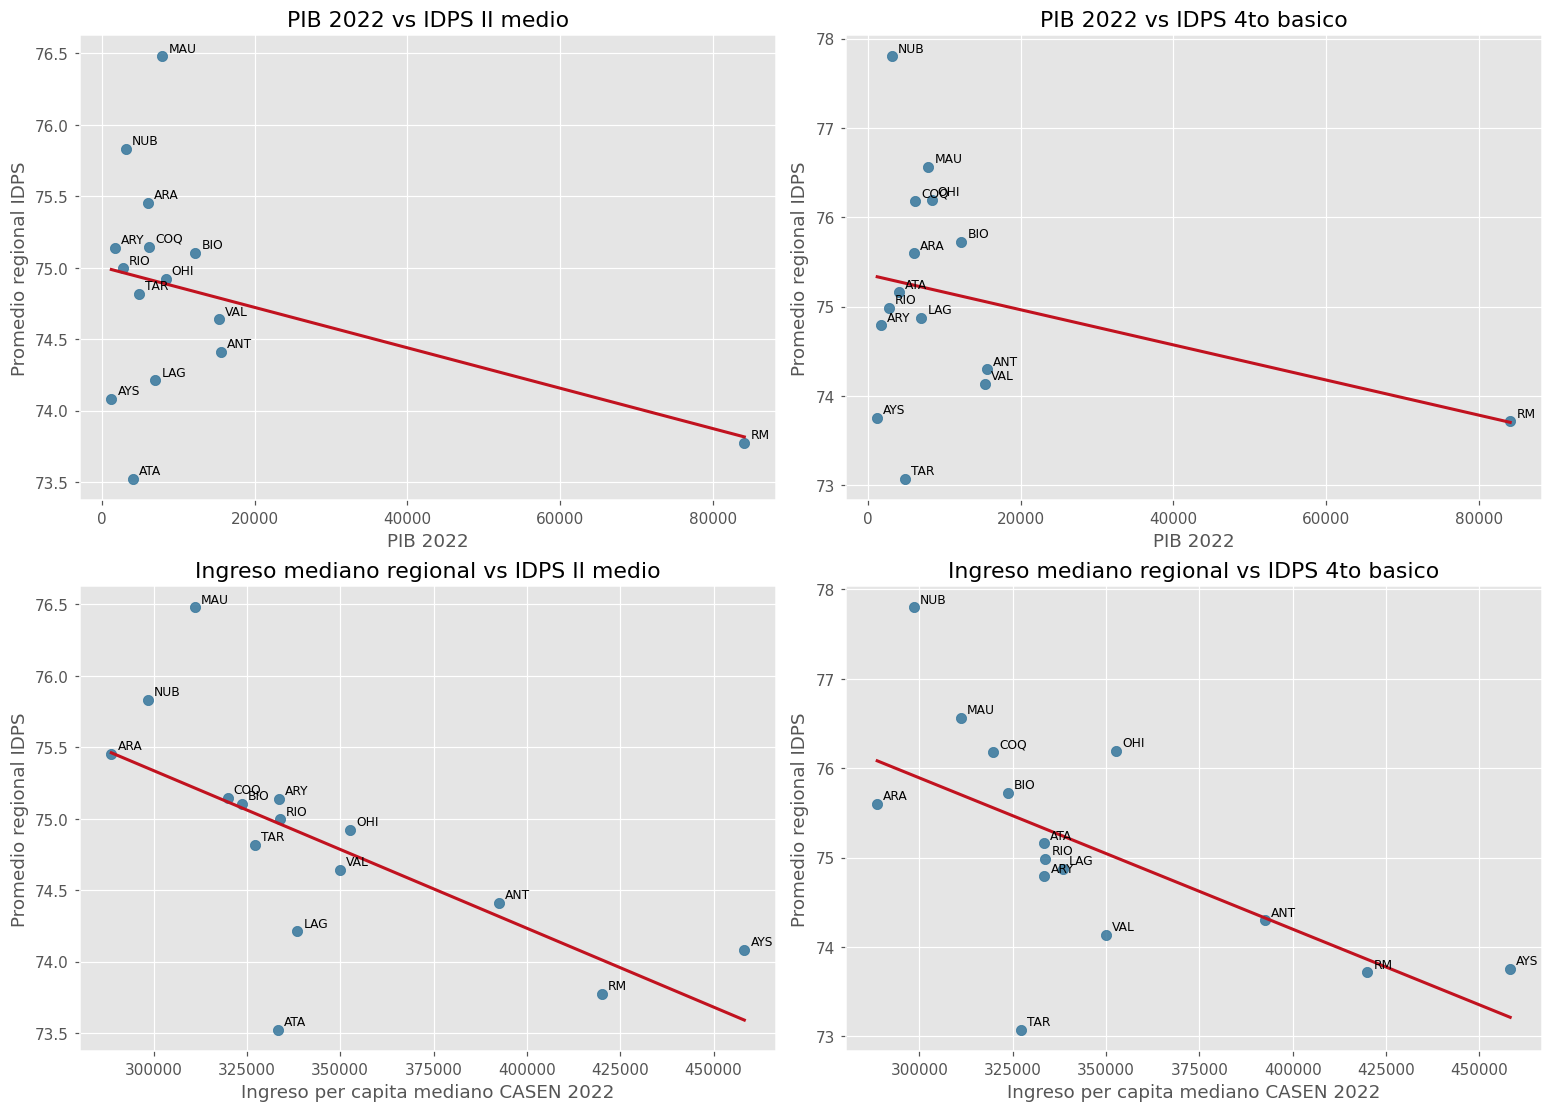

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

graficos = [
    ('pib_2022', 'idps_2m', 'PIB 2022 vs IDPS II medio', 'PIB 2022'),
    ('pib_2022', 'idps_4b', 'PIB 2022 vs IDPS 4to basico', 'PIB 2022'),
    ('ingreso_pc_mediana', 'idps_2m', 'Ingreso mediano regional vs IDPS II medio', 'Ingreso per capita mediano CASEN 2022'),
    ('ingreso_pc_mediana', 'idps_4b', 'Ingreso mediano regional vs IDPS 4to basico', 'Ingreso per capita mediano CASEN 2022')
]

for ax, (x_col, y_col, titulo, x_label) in zip(axes.flat, graficos):
    temp = region_analisis.dropna(subset=[x_col, y_col]).copy()
    x = temp[x_col].to_numpy(dtype=float)
    y = temp[y_col].to_numpy(dtype=float)

    ax.scatter(x, y, s=45, color='#2a6f97', alpha=0.8)
    if len(temp) >= 2:
        coef = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = coef[0] * x_line + coef[1]
        ax.plot(x_line, y_line, color='#c1121f', linewidth=2)

    for _, row in temp.iterrows():
        ax.annotate(row['region_sigla'], (row[x_col], row[y_col]), fontsize=8, xytext=(4, 3), textcoords='offset points')

    ax.set_title(titulo)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Promedio regional IDPS')

plt.show()


### Hallazgos preliminares de la semana 2

El analisis exploratorio inicial deja cinco resultados importantes:

- Con los datos disponibles, **no aparece una relacion positiva simple** entre mayor PIB regional total y mejor IDPS regional.
- La Region Metropolitana concentra con mucha distancia el mayor PIB, pero no lidera los puntajes IDPS; eso hace que el PIB total se comporte mas como medida de tamano economico que como indicador limpio de bienestar regional.
- El **crecimiento del PIB entre 2018 y 2022** muestra una asociacion positiva debil a moderada con IDPS, sobre todo en II medio, pero el patron sigue siendo sensible al pequeno numero de regiones.
- Regiones como **Maule, Nuble, OHiggins y Coquimbo** aparecen con desempenos IDPS altos sin estar entre las de mayor PIB total, lo que sugiere que el desarrollo economico no se traduce automaticamente en mejores resultados educativos.
- El apoyo con la base urbana del **Censo 2024** no cambia la conclusion central: variables como escolaridad urbana e internet sirven para contextualizar el territorio, pero no revierten el hecho de que el PIB total regional no predice de forma clara el IDPS.

En esta etapa, la respuesta exploratoria mas prudente es que **no basta con mirar el PIB total regional** para afirmar que una region economicamente mas desarrollada presenta mejor desempeno educativo.

## Semana 3. Profundizacion del contexto

### Contexto de las bases utilizadas

A esta altura del avance ya no basta con mostrar una correlacion. Tambien es necesario justificar que significa cada fuente y que puede realmente decirnos.

- **PIB regional** entrega una aproximacion a la actividad economica de cada territorio, pero en este archivo funciona mejor como medida de escala economica regional que como indicador perfecto de desarrollo.
- **IDPS 2022** entrega indicadores educacionales no academicos por establecimiento, luego agregados por region.
- **CASEN 2022** aporta un contexto mas fino sobre ingreso, pobreza y escolaridad, lo que ayuda a interpretar mejor el concepto de desarrollo economico.
- **Base_urbanos_CPV24.csv** aporta contexto urbano regional sobre escolaridad, asistencia e internet; no reemplaza el resultado educativo, pero ayuda a describir mejor el territorio.

### Evaluacion de otras bases del proyecto

- La base de la **pregunta 3** si resulta util como apoyo contextual, porque entrega variables regionales agregables.
- La base de la **pregunta 5** no se incorpora como eje principal, porque describe matricula y oferta universitaria por carrera o sede, no desempeno escolar regional ni trayectoria previa por territorio.

### Formulacion precisa para esta etapa

Con las bases disponibles, la version metodologicamente mas consistente de la pregunta es:

> **Existe una asociacion entre el nivel de actividad economica regional y los puntajes regionales promedio de IDPS en 2022?**

Si el grupo quisiera responder la pregunta en un sentido mas estricto sobre desempeno academico, convendria complementar con una medida regional de SIMCE u otro indicador academico.

In [9]:
glosario = pd.DataFrame([
    {'termino': 'PIB regional', 'tipo': 'Concepto', 'descripcion': 'Producto interno bruto regional medido en volumen. En este avance se usa el dato 2022 del archivo disponible.'},
    {'termino': 'pib_crecimiento_2018_2022_pct', 'tipo': 'Indicador construido', 'descripcion': 'Variacion porcentual del PIB regional entre 2018 y 2022.'},
    {'termino': 'IDPS', 'tipo': 'Concepto', 'descripcion': 'Indicadores de Desarrollo Personal y Social reportados por establecimiento y luego agregados por region.'},
    {'termino': 'idps_2m', 'tipo': 'Indicador regional', 'descripcion': 'Promedio regional del puntaje IDPS de II medio.'},
    {'termino': 'idps_4b', 'tipo': 'Indicador regional', 'descripcion': 'Promedio regional del puntaje IDPS de 4to basico.'},
    {'termino': 'ingreso_pc_prom', 'tipo': 'Indicador CASEN', 'descripcion': 'Ingreso per capita promedio regional, ponderado con el factor de expansion de personas.'},
    {'termino': 'ingreso_pc_mediana', 'tipo': 'Indicador CASEN', 'descripcion': 'Mediana regional del ingreso per capita corregido del hogar.'},
    {'termino': 'pobreza_total_pct', 'tipo': 'Indicador CASEN', 'descripcion': 'Porcentaje regional estimado de personas en pobreza por ingresos.'},
    {'termino': 'pobreza_multi_pct', 'tipo': 'Indicador CASEN', 'descripcion': 'Porcentaje regional estimado de pobreza multidimensional.'},
    {'termino': 'prom_escolaridad18_urbana', 'tipo': 'Indicador Censo 2024', 'descripcion': 'Promedio ponderado de escolaridad en poblacion de 18 anios y mas dentro de la base urbana del censo.'},
    {'termino': 'asistencia_superior_pct_urbana', 'tipo': 'Indicador Censo 2024', 'descripcion': 'Porcentaje estimado de poblacion urbana regional asistiendo a educacion superior dentro de la base urbana.'},
    {'termino': 'internet_pct_urbana', 'tipo': 'Indicador Censo 2024', 'descripcion': 'Porcentaje estimado de poblacion urbana regional con acceso a internet dentro de la base urbana.'},
    {'termino': 'expr', 'tipo': 'Variable CASEN', 'descripcion': 'Factor de expansion usado para resumir variables de personas a nivel regional.'}
])

glosario

,termino,tipo,descripcion
0,PIB regional,Concepto,Producto interno bruto regional medido en volu...
1,pib_crecimiento_2018_2022_pct,Indicador construido,Variacion porcentual del PIB regional entre 20...
2,IDPS,Concepto,Indicadores de Desarrollo Personal y Social re...
3,idps_2m,Indicador regional,Promedio regional del puntaje IDPS de II medio.
4,idps_4b,Indicador regional,Promedio regional del puntaje IDPS de 4to basico.
5,ingreso_pc_prom,Indicador CASEN,"Ingreso per capita promedio regional, ponderad..."
6,ingreso_pc_mediana,Indicador CASEN,Mediana regional del ingreso per capita correg...
7,pobreza_total_pct,Indicador CASEN,Porcentaje regional estimado de personas en po...
8,pobreza_multi_pct,Indicador CASEN,Porcentaje regional estimado de pobreza multid...
9,prom_escolaridad18_urbana,Indicador Censo 2024,Promedio ponderado de escolaridad en poblacion...


In [10]:
contexto_regiones = region_analisis[['region', 'region_corta', 'region_sigla', 'pib_2022', 'idps_2m', 'idps_4b', 'prom_escolaridad18_urbana', 'asistencia_superior_pct_urbana', 'internet_pct_urbana']].copy()
contexto_regiones['pib_rank'] = contexto_regiones['pib_2022'].rank(ascending=False, method='min')
contexto_regiones['idps_2m_rank'] = contexto_regiones['idps_2m'].rank(ascending=False, method='min')
contexto_regiones['idps_4b_rank'] = contexto_regiones['idps_4b'].rank(ascending=False, method='min')

print('Tabla de contexto para comparar peso economico, IDPS y apoyo urbano del Censo 2024')
display(contexto_regiones.sort_values('pib_rank').round(2))


Tabla de contexto para comparar peso economico, IDPS y apoyo urbano del Censo 2024


,region,region_corta,region_sigla,pib_2022,idps_2m,idps_4b,prom_escolaridad18_urbana,asistencia_superior_pct_urbana,internet_pct_urbana,pib_rank,idps_2m_rank,idps_4b_rank
6,13,Metropolitana,RM,"84,131.12",73.78,73.72,12.72,4.73,33.73,1.00,14.00,14.00
2,2,Antofagasta,ANT,"15,561.58",74.41,74.30,12.48,3.95,32.53,2.00,11.00,11.00
5,5,Valparaiso,VAL,"15,257.79",74.64,74.13,12.45,4.85,35.04,3.00,10.00,12.00
10,8,Biobio,BIO,"12,201.72",75.11,75.72,12.18,5.49,33.54,4.00,6.00,5.00
7,6,OHiggins,OHI,"8,328.31",74.92,76.20,11.77,3.56,32.99,5.00,8.00,3.00
8,7,Maule,MAU,"7,897.50",76.48,76.56,11.63,4.37,33.22,6.00,1.00,2.00
13,10,Los Lagos,LAG,"6,957.47",74.21,74.88,11.72,3.81,34.52,7.00,12.00,9.00
4,4,Coquimbo,COQ,"6,125.84",75.15,76.18,12.22,4.55,32.72,8.00,4.00,4.00
11,9,La Araucania,ARA,"5,955.74",75.45,75.60,11.99,4.91,34.27,9.00,3.00,6.00
1,1,Tarapaca,TAR,"4,868.17",74.82,73.07,12.29,3.68,31.61,10.00,9.00,15.00


### Limitaciones detectadas en la profundizacion del contexto

- El archivo de PIB disponible deja fuera a **Magallanes** en el cruce utilizable, por lo que el analisis queda con 15 regiones.
- Aunque la hoja de metadatos indica frecuencia trimestral, el archivo disponible para este trabajo contiene en la practica un corte anual por anio.
- El **PIB total** no es equivalente a desarrollo economico per capita; por eso se complementa con ingreso y pobreza regional de CASEN.
- El resultado educativo usado es **IDPS**, no una medida academica directa.
- La base de la pregunta 3 usada como apoyo corresponde a **contexto urbano**, por lo que no representa por si sola a toda la region.
- La base de la pregunta 5 no fue incorporada como variable principal porque no permite observar directamente desempeno escolar regional ni region de origen del estudiante.
- El numero de observaciones es pequeno, por lo que cualquier correlacion es sensible a outliers como la Region Metropolitana.

### Preguntas de investigacion preliminares para la siguiente fase

1. Conviene definir desarrollo economico con PIB total, crecimiento del PIB, ingreso regional o una combinacion de indicadores?
2. El patron cambia si se analiza II medio y 4to basico por separado?
3. Una medida academica directa como SIMCE regional cambia la conclusion preliminar observada con IDPS?
4. Regiones con menor PIB pero alto IDPS comparten caracteristicas escolares o territoriales que ayuden a explicar el resultado?
5. Las variables urbanas del Censo 2024 ayudan a distinguir mejor entre escala economica regional y condiciones educativas del territorio?

Con esto queda cubierto el avance solicitado hasta la **semana 3**, incluyendo analisis exploratorio, contexto, glosario y limitaciones metodologicas.